AutoEncoder is made of an encoder and decoder

In [7]:
from tensorflow.keras.layers import Dense, Input, LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.models import Model

from tensorflow.keras.datasets import fashion_mnist

In [8]:
data = fashion_mnist.load_data()
(trainFeatures, trainTarget), (testFeatures, testTarget) = data

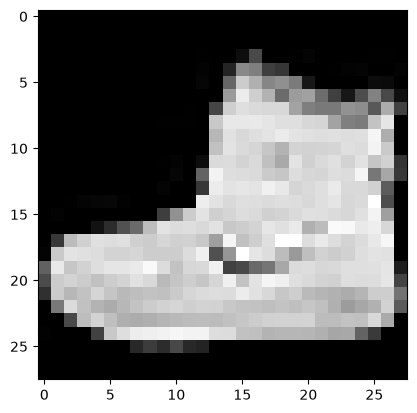

In [9]:
import matplotlib.pyplot as plt

plt.imshow(trainFeatures[0], cmap='gray')

In [ ]:
trainFeaturesNew = trainFeatures / 255 # normalisation
testFeaturesNew = testFeatures / 255

In [59]:
import numpy as np

trainFeaturesNoisy = trainFeaturesNew + 0.5*np.random.normal(loc=0, scale=1, size=trainFeaturesNew.shape)
testFeaturesNoisy = testFeaturesNew + 0.5*np.random.normal(loc=0, scale=1, size=testFeaturesNew.shape)

In [58]:
np.random.normal(loc=0, scale=1, size=5)

array([ 0.87033911,  1.88183845,  0.5302902 , -1.05975495, -1.00673846])

In [21]:
trainFeaturesNew.shape

(60000, 28, 28)

In [60]:
# building layers for encoder

inputLayer = Input(shape=(28, 28)) # 784 (28*28)
lstmLayer = LSTM(128, activation='relu', return_state=True)(inputLayer) # for forgetting unecessary data (narrowed down from 784 to 128)

hiddenState = lstmLayer[1]

encoder = Model(inputLayer, hiddenState) # encoder to compress the image to something simple

In [61]:
# building layers for decoder

inputLayerD = Input(shape=(128, )) # taking input from encoder, must be the shape of the encoder's output
repeatVectorLayer = RepeatVector(28)(inputLayerD) # repreat 28 times - 28 rows
lstmLayer = LSTM(128, activation='relu', return_sequences=True)(repeatVectorLayer)
dense = TimeDistributed(Dense(28, activation='sigmoid'))(lstmLayer)

decoder = Model(inputLayerD, dense) # decoder to rebuild the image from simplified data

In [14]:
# trainFeaturesNoise # research how to add noise to images

In [63]:
autoEncoder = Model(inputLayer, decoder(encoder(inputLayer)))
autoEncoder.compile(optimizer='adam', loss='binary_crossentropy')
autoEncoder.fit(trainFeaturesNoisy, trainFeaturesNew, epochs=10, batch_size=256, shuffle=True, validation_data=(testFeaturesNoisy, testFeaturesNew))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 87s 330ms/step - loss: 0.3362 - val_loss: 0.3181
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 326ms/step - loss: 0.3114 - val_loss: 0.3097
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 103s 438ms/step - loss: 0.3053 - val_loss: 0.3081
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 329ms/step - loss: 0.3016 - val_loss: 0.3032
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 70s 296ms/step - loss: 0.2992 - val_loss: 0.2998
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 313ms/step - loss: 0.2967 - val_loss: 0.2999
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 317ms/step - loss: 0.2958 - val_loss: 0.2984
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 77s 327ms/step - loss: 0.2942 - val_loss: 0.2955
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 72s 304ms/step - loss: 0.2930 - val_loss: 0.2955
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 60s 256ms/step - loss: 0.2921 - val_loss: 0.2940


In [ ]:
prediction = autoEncoder.predict(trainFeatures[0])
prediction

In [ ]:
plt.imshow(trainFeatures[0], cmap='gray')
plt.imshow(trainFeaturesNoisy[0]*255, cmap='gray')
#plt.imshow(prediction, cmap='gray')

In [ ]:
plt.subplot()